# Physics-Informed Machine Learning
## Notebook 03 — Neural Networks as Mathematical Functions

### Objective

In the previous notebooks we learned:

- What an ODE is
- How systems of ODEs work
- How numerical solvers work
- The Lorenz system
- Why Lorenz dynamics are interesting

Now we return to neural networks.

The goal of this notebook is to understand a neural network from a
different perspective.

Instead of thinking:

    input → prediction/classification

we will think:

    x → neural network → f(x)

In other words, the neural network becomes a mathematical function approximator.

We will learn:

1. A neural network can approximate mathematical functions
2. PyTorch tensors
3. Building a neural network
4. Training a neural network on a mathematical function
5. Automatic differentiation
6. Computing dy/dx using a neural network
7. Comparing analytical and neural-network derivatives

This is the key bridge toward Physics-Informed Neural Networks.

# 1. A Neural Network as a Function

Suppose we have a mathematical function:

    y = sin(x)

We can evaluate it directly:

    x → sin(x) → y

A neural network can instead learn an approximation:

    x → Neural Network → ŷ

where:

    ŷ ≈ sin(x)

The neural network does not necessarily know the equation:

    y = sin(x)

It simply sees examples such as:

    x       y
    ----------------
    0.0     0.0
    0.1     0.1
    0.2     0.2
    ...

and learns a function that approximates the relationship.

Mathematically, we can write:

    ŷ = NN(x; θ)

where θ represents all trainable parameters of the neural network.

In [1]:
# For CUDA 12.6 (Recommended Stable)
%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu126

# OR For CPU-only (If you don't have an NVIDIA GPU)
%pip install torch torchvision torchaudio --index-url https://pytorch.org


Note: you may need to restart the kernel to use updated packages.


c:\Users\sanir\AppData\Local\Programs\Python\Python313\python.exe: No module named pip


Note: you may need to restart the kernel to use updated packages.


c:\Users\sanir\AppData\Local\Programs\Python\Python313\python.exe: No module named pip


In [3]:
import sys
print("Notebook is using:", sys.executable)


Notebook is using: c:\Users\sanir\AppData\Local\Programs\Python\Python313\python.exe


In [2]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

print("PyTorch version:", torch.__version__)

PyTorch version: 2.13.0+cpu


# 2. Generate Training Data

We will create data from:

    y = sin(x)

The neural network will receive `x` and try to predict `y`.

Important:

The neural network does NOT receive the equation itself.

It only receives examples.

In [3]:
# Reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Generate input values
x = np.linspace(-2 * np.pi, 2 * np.pi, 500)

# Generate target values
y = np.sin(x)

# Convert NumPy arrays into PyTorch tensors
x_tensor = torch.tensor(x, dtype=torch.float32).reshape(-1, 1)
y_tensor = torch.tensor(y, dtype=torch.float32).reshape(-1, 1)

print("x shape:", x_tensor.shape)
print("y shape:", y_tensor.shape)

x shape: torch.Size([500, 1])
y shape: torch.Size([500, 1])


# 3. Visualize the Training Function

Before training anything, let's see the function that the neural network
will try to learn.

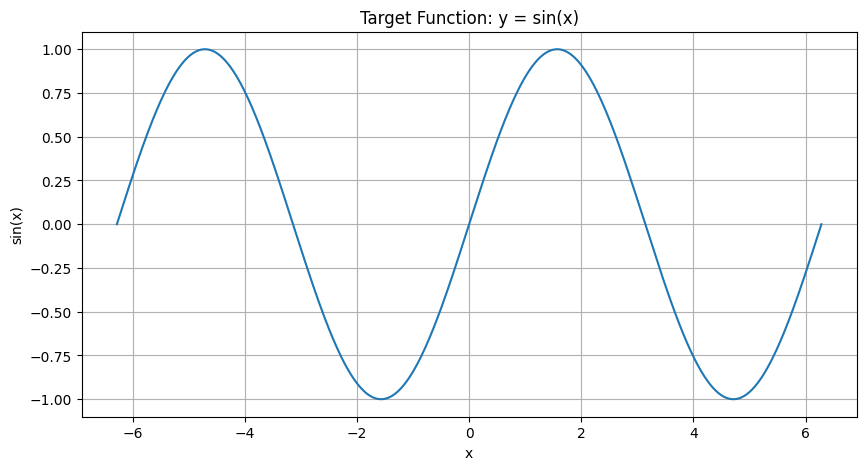

In [4]:
plt.figure(figsize=(10, 5))

plt.plot(x, y)

plt.xlabel("x")
plt.ylabel("sin(x)")
plt.title("Target Function: y = sin(x)")
plt.grid(True)

plt.show()

# 4. Building the Neural Network

We will use a simple fully connected neural network.

Architecture:

    Input
      ↓
    Linear layer
      ↓
    Tanh
      ↓
    Linear layer
      ↓
    Tanh
      ↓
    Linear layer
      ↓
    Output

The network receives:

    x

and produces:

    ŷ

In [5]:
class FunctionApproximator(nn.Module):
    """
    Neural network used to approximate a mathematical function.

    Input:
        x

    Output:
        predicted y
    """

    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(1, 32),
            nn.Tanh(),

            nn.Linear(32, 32),
            nn.Tanh(),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.network(x)

# 5. Create the Model

At this point the network has random parameters.

Therefore its predictions will initially be meaningless.

Training will modify these parameters.

The important idea is:

    θ_initial
       ↓
    training
       ↓
    θ_learned

The learned parameters make the network approximate `sin(x)`.

In [6]:
model = FunctionApproximator()

print(model)

FunctionApproximator(
  (network): Sequential(
    (0): Linear(in_features=1, out_features=32, bias=True)
    (1): Tanh()
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): Tanh()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)


# 6. Making a Prediction Before Training

Let's see what the randomly initialized network predicts.

Remember:

    Neural Network(x) → prediction

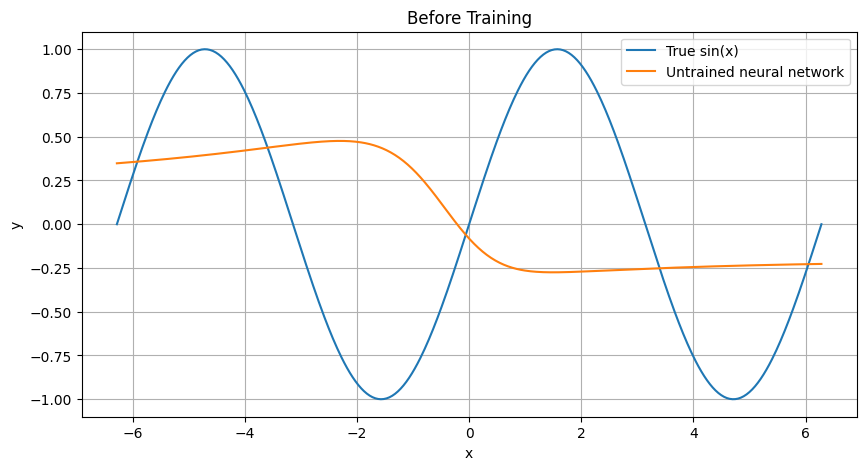

In [7]:
with torch.no_grad():
    initial_prediction = model(x_tensor)

plt.figure(figsize=(10, 5))

plt.plot(
    x,
    y,
    label="True sin(x)"
)

plt.plot(
    x,
    initial_prediction.numpy(),
    label="Untrained neural network"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Before Training")
plt.grid(True)
plt.legend()

plt.show()

# 7. Training the Network

We use Mean Squared Error:

    MSE = mean((ŷ - y)²)

The training process is:

    x
    ↓
    Neural Network
    ↓
    ŷ
    ↓
    Compare with y
    ↓
    Loss
    ↓
    Backpropagation
    ↓
    Update parameters
    ↓
    Repeat

This is standard neural-network training.

Nothing about physics or differential equations has been introduced yet.

In [8]:
# Loss function
loss_function = nn.MSELoss()

# Optimizer
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

# Number of training iterations
epochs = 3000

loss_history = []

for epoch in range(epochs):

    # Forward pass
    prediction = model(x_tensor)

    # Calculate loss
    loss = loss_function(prediction, y_tensor)

    # Clear previous gradients
    optimizer.zero_grad()

    # Backpropagation
    loss.backward()

    # Update parameters
    optimizer.step()

    loss_history.append(loss.item())

    if epoch % 500 == 0:
        print(
            f"Epoch {epoch:4d} | Loss = {loss.item():.8f}"
        )

Epoch    0 | Loss = 0.60614461
Epoch  500 | Loss = 0.04501947
Epoch 1000 | Loss = 0.00216872
Epoch 1500 | Loss = 0.00022186
Epoch 2000 | Loss = 0.00007151
Epoch 2500 | Loss = 0.00003764


# 8. Visualizing the Training Loss

The loss should decrease as the neural network learns the function.

This is one of the most basic but important diagnostic plots in machine learning.

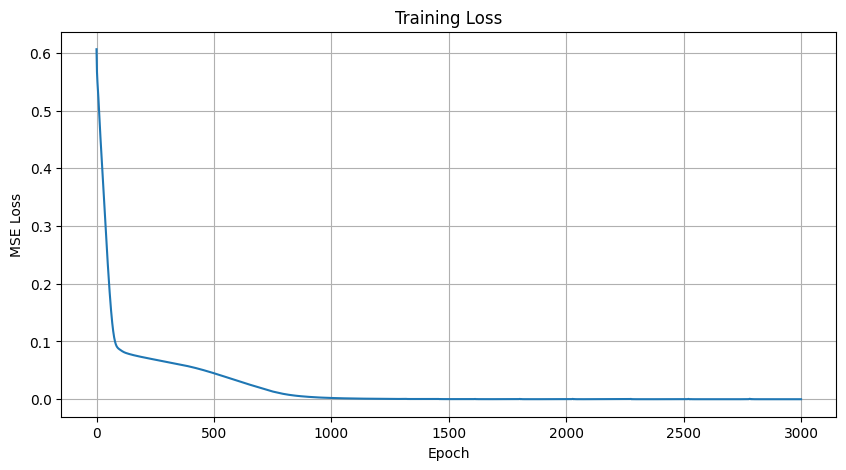

In [9]:
plt.figure(figsize=(10, 5))

plt.plot(loss_history)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training Loss")
plt.grid(True)

plt.show()

# 9. How Well Did the Network Learn?

Now let's compare:

    True function:
        sin(x)

against:

    Neural network:
        NN(x)

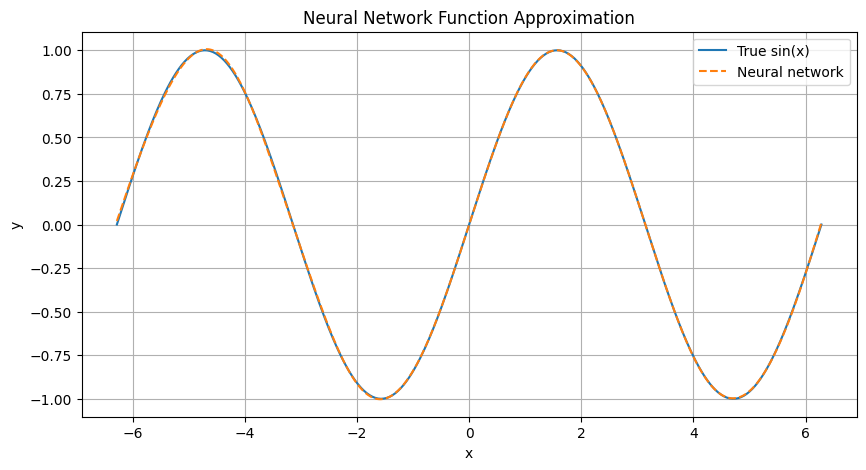

In [11]:
model.eval()

with torch.no_grad():
    prediction = model(x_tensor)

prediction = prediction.numpy().flatten()

plt.figure(figsize=(10, 5))

plt.plot(
    x,
    y,
    label="True sin(x)"
)

plt.plot(
    x,
    prediction,
    "--",
    label="Neural network"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Neural Network Function Approximation")
plt.grid(True)
plt.legend()

plt.show()


# 10. The Important Shift in Perspective

We have just trained a neural network to represent:

    y = sin(x)

After training, we can think of the network as approximately defining a function:

    fθ(x) ≈ sin(x)

This perspective is extremely important.

We are no longer required to think of the neural network only as:

    classifier
    predictor
    regression model

We can think of it as:

    a flexible mathematical function

This is exactly how we will use neural networks in PINNs.

For a PINN, instead of learning:

    f(x) ≈ sin(x)

we might want:

    f(t) ≈ y(t)

where `y(t)` is the unknown solution of a differential equation.